# Monte Carlo

n método Monte Carlo es un procedimiento computacional que usa números aleatorios para aproximar cantidades probabilísticas o matemáticas.

$$
\text{Cantidad teórica} \approx \text{promedio de muchos experimentos aleatorios}
$$

Formalmente, si queremos calcular

$$
E[X]
$$

podemos aproximarlo con

$$
\hat{E}[X]=\frac{1}{N} \sum_{i=1}^N X_i
$$

donde $X_i$ son simulaciones independientes.
Esto funciona por la Ley de los Grandes Números.

# Urna de Pólya

La urna de Pólya es un proceso estocástico dinámico pues el sistema cambia después de cada extracción, y las probabilidades dependen de el evento pasado.


EL código simula una trayectoria de una urna de Pólya por MC. El algoritmo hace esto:

1)  Simular el experimento muchas veces
2)  Registrar los resultados
3)  Promediar

$$
P\left(R_2\right) \approx \frac{\text { veces que sale roja en la simulación }}{\text { número total de simulaciones }}
$$


Parámetros que usa:

    r : Número inicial de bolas rojas.
    
    b : Número inicial de bolas blancas.
    
    c :  Número de bolas que se agregan del color extraído.
    
    n_steps : Número de sorteos.
    
    rng : np.random.Generator o None (Generador aleatorio).

EL programa vca a regresar: 

    draws : list[str]
        Lista con 'R' o 'B' según el color extraído en cada paso.

        
    red_proportions : list[float]
        Proporción de rojas en la urna después de cada paso.

 Valores teóricos 
P(R1)                        = 0.600000
P(B1)                        = 0.400000
P(R2|R1)                     = 0.666667
P(R2|B1)                     = 0.500000
P(R2) teórica                = 0.600000

 Estimación por simulación 
P(R1)                        = 0.600715
P(B1)                        = 0.399285
P(R2)                        = 0.599945
P(R2|R1)                     = 0.665915
P(R2|B1)                     = 0.500695
P(R2) por Prob. Tot          = 0.599945


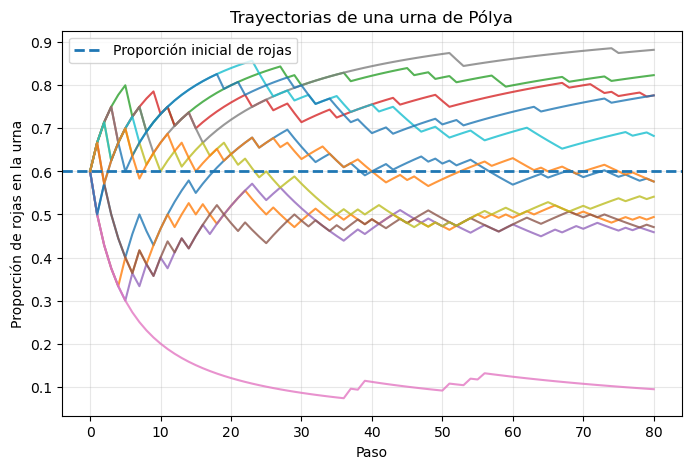

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def polya_urn_simulation(r, b, c, n_steps, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    red = r
    white = b

    draws = []
    red_proportions = [red / (red + white)]

    for _ in range(n_steps):
        p_red = red / (red + white)

        if rng.random() < p_red:
            draws.append("R")
            red += c
        else:
            draws.append("B")
            white += c

        red_proportions.append(red / (red + white))

    return draws, red_proportions

# Estima por MC : P(R2) = P(R2|R1)P(R1) + P(R2|B1)P(B1)
def estimate_second_draw_probabilities(r, b, c, n_trials=100000, seed=123):
    rng = np.random.default_rng(seed)

    count_R1 = 0
    count_B1 = 0
    count_R2 = 0
    count_R2_given_R1 = 0
    count_R2_given_B1 = 0

    for _ in range(n_trials):
        # Estado inicial
        red = r
        white = b

        # Primer sorteo
        if rng.random() < red / (red + white):
            first = "R"
            red += c
            count_R1 += 1
        else:
            first = "B"
            white += c
            count_B1 += 1

        # Segundo sorteo
        if rng.random() < red / (red + white):
            second = "R"
            count_R2 += 1
            if first == "R":
                count_R2_given_R1 += 1
            else:
                count_R2_given_B1 += 1

    p_R1 = count_R1 / n_trials
    p_B1 = count_B1 / n_trials
    p_R2 = count_R2 / n_trials

    p_R2_given_R1 = count_R2_given_R1 / count_R1 if count_R1 > 0 else np.nan
    p_R2_given_B1 = count_R2_given_B1 / count_B1 if count_B1 > 0 else np.nan

    p_total_est = p_R2_given_R1 * p_R1 + p_R2_given_B1 * p_B1

    return {
        "P(R1)": p_R1,
        "P(B1)": p_B1,
        "P(R2)": p_R2,
        "P(R2|R1)": p_R2_given_R1,
        "P(R2|B1)": p_R2_given_B1,
        "P(R2) por Prob. Tot": p_total_est,
    }

# Valores teóricos para el segundo sorteo.
def theoretical_second_draw_probabilities(r, b, c):
    p_R1 = r / (r + b)
    p_B1 = b / (r + b)
    p_R2_given_R1 = (r + c) / (r + b + c)
    p_R2_given_B1 = r / (r + b + c)
    p_R2 = p_R2_given_R1 * p_R1 + p_R2_given_B1 * p_B1

    return {
        "P(R1)": p_R1,
        "P(B1)": p_B1,
        "P(R2|R1)": p_R2_given_R1,
        "P(R2|B1)": p_R2_given_B1,
        "P(R2) teórica": p_R2,
    }

def plot_polya_trajectories(r, b, c, n_steps=100, n_paths=10, seed=1234):

    
    rng = np.random.default_rng(seed)

    plt.figure(figsize=(8, 5))

    for _ in range(n_paths):
        _, red_props = polya_urn_simulation(r, b, c, n_steps, rng=rng)
        plt.plot(range(len(red_props)), red_props, alpha=0.8)

    plt.axhline(r / (r + b), linestyle="--", linewidth=2,
                label="Proporción inicial de rojas")
    plt.xlabel("Paso")
    plt.ylabel("Proporción de rojas en la urna")
    plt.title("Trayectorias de una urna de Pólya")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


# Parámetros
r = 3
b = 2 
c = 1   
n_trials = 200000

theory = theoretical_second_draw_probabilities(r, b, c)

print(" Valores teóricos ")
for k, v in theory.items():
    print(f"{k:28s} = {v:.6f}")

# Resultados simulación
sim = estimate_second_draw_probabilities(r, b, c, n_trials=n_trials, seed=42)

print("\n Estimación por simulación ")
for k, v in sim.items():
    print(f"{k:28s} = {v:.6f}")

plot_polya_trajectories(r, b, c, n_steps=80, n_paths=12, seed=2025)

Con $r=3, b=2, c=1$, teóricamente:

$$
\begin{gathered}
P\left(R_1\right)=\frac{3}{5}=0.6 \\
P\left(R_2 \mid R_1\right)=\frac{4}{6}=\frac{2}{3} \approx 0.6667 \\
P\left(R_2 \mid B_1\right)=\frac{3}{6}=0.5
\end{gathered}
$$


Entonces:

$$
P\left(R_2\right)=\frac{2}{3}(0.6)+0.5(0.4)=0.4+0.2=0.6
$$

o sea:

$$
P\left(R_2\right)=0.6=P\left(R_1\right)
$$